# Event Attendance Predictor — Deep EDA

## Setup

In [57]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    skew, kurtosis, ks_2samp, chi2_contingency,
    pointbiserialr, mannwhitneyu
)
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

TRAIN_PATH = "/kaggle/input/datasets/neeldipeshshah/event-attendance-predictor-cleaned-data/train_clean.csv"
TEST_PATH = "/kaggle/input/datasets/neeldipeshshah/event-attendance-predictor-cleaned-data/test_clean.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# FIX: club_member / event_time sometimes still arrive as raw text
# ("Yes"/"No", "09:00") if the cleaned-data Kaggle Dataset is behind the
# cleanup notebook. Normalize them here so this notebook can't crash on it,
# matching exactly what the cleanup notebook's standardize_categoricals() does.
# (checks pd.api.types.is_numeric_dtype instead of `== object` so this also
# catches pandas' newer StringDtype columns, not just legacy object dtype.)
if not pd.api.types.is_numeric_dtype(train["club_member"]):
    train["club_member"] = train["club_member"].map({"Yes": 1, "No": 0}).astype(float)
if not pd.api.types.is_numeric_dtype(test["club_member"]):
    test["club_member"] = test["club_member"].map({"Yes": 1, "No": 0}).astype(float)

if not pd.api.types.is_numeric_dtype(train["event_time"]):
    train["event_time"] = pd.to_datetime(train["event_time"], format="%H:%M", errors="coerce").dt.hour
if not pd.api.types.is_numeric_dtype(test["event_time"]):
    test["event_time"] = pd.to_datetime(test["event_time"], format="%H:%M", errors="coerce").dt.hour

TARGET = "attended"

# The cleaned data may contain the 5 unlabeled training rows.
# They are excluded from target-based analysis, not discarded from the source data.
labeled = train.dropna(subset=[TARGET]).copy()

NUM_COLS = [
    "registration_days_before",
    "previous_events_registered",
    "previous_events_attended",
    "travel_distance_km",
    "club_member",
    "event_time"
]

CAT_COLS = [
    "event_type",
    "event_day"
]

print("Raw cleaned train:", train.shape)
print("Labeled train    :", labeled.shape)
print("Test             :", test.shape)
print("Unlabeled train  :", train[TARGET].isna().sum())


Raw cleaned train: (496, 10)
Labeled train    : (496, 10)
Test             : (100, 9)
Unlabeled train  : 0


## Data Audit

In [58]:

audit = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_%": (train.isna().mean() * 100).round(2),
    "unique": train.nunique(dropna=True)
})

display(audit)

print("Duplicate rows:", train.duplicated().sum())
print("Duplicate student IDs:", train["student_id"].duplicated().sum())
print(
    "Invalid previous attendance:",
    (train["previous_events_attended"] > train["previous_events_registered"]).sum()
)


,dtype,missing,missing_%,unique
student_id,object,0,0.0000,495
event_type,object,0,0.0000,5
registration_days_before,int64,0,0.0000,15
previous_events_registered,int64,0,0.0000,12
previous_events_attended,int64,0,0.0000,9
club_member,float64,0,0.0000,2
event_day,object,0,0.0000,7
event_time,float64,0,0.0000,5
travel_distance_km,float64,0,0.0000,152
attended,int64,0,0.0000,2


Duplicate rows: 0
Duplicate student IDs: 1
Invalid previous attendance: 7


## Target

,count,percentage
attended,,
0,183,36.9000
1,313,63.1000


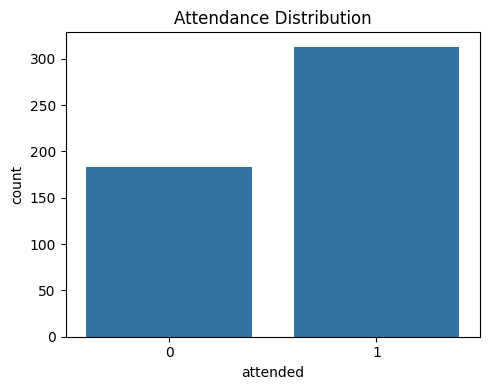

Positive rate: 63.10%


In [59]:

target_table = labeled[TARGET].value_counts().sort_index().to_frame("count")
target_table["percentage"] = target_table["count"] / len(labeled) * 100

display(target_table.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=labeled, x=TARGET)
plt.title("Attendance Distribution")
plt.tight_layout()
plt.show()

print("Positive rate:", f"{labeled[TARGET].mean():.2%}")


## Numerical Statistics

In [60]:

stats = labeled[NUM_COLS].describe().T
stats["variance"] = labeled[NUM_COLS].var()
stats["cv_%"] = (
    labeled[NUM_COLS].std()
    / labeled[NUM_COLS].mean().replace(0, np.nan)
    * 100
)
stats["skewness"] = labeled[NUM_COLS].apply(skew)
stats["excess_kurtosis"] = labeled[NUM_COLS].apply(
    lambda x: kurtosis(x.dropna(), fisher=True)
)
stats["IQR"] = (
    labeled[NUM_COLS].quantile(0.75)
    - labeled[NUM_COLS].quantile(0.25)
)

display(
    stats[
        [
            "count", "mean", "50%", "std", "variance", "cv_%",
            "min", "max", "skewness", "excess_kurtosis", "IQR"
        ]
    ].round(4)
)


,count,mean,50%,std,variance,cv_%,min,max,skewness,excess_kurtosis,IQR
registration_days_before,496.0000,7.2984,7.0000,4.2125,17.7451,57.7182,0.0000,14.0000,-0.0912,-1.1073,7.0000
previous_events_registered,496.0000,4.0645,4.0000,1.9196,3.6847,47.2273,0.0000,11.0000,0.3611,0.1010,2.0000
previous_events_attended,496.0000,2.8004,3.0000,1.5810,2.4995,56.4552,0.0000,8.0000,0.7082,0.4104,2.0000
travel_distance_km,496.0000,6.4502,5.5000,4.4542,19.8397,69.0549,0.5000,25.0000,1.2518,1.8169,5.6250
club_member,496.0000,0.6452,1.0000,0.4789,0.2294,74.2369,0.0000,1.0000,-0.6068,-1.6318,1.0000
event_time,496.0000,14.4093,14.0000,3.1417,9.8705,21.8036,9.0000,18.0000,-0.4244,-1.1154,7.0000


## Distributions & Outliers

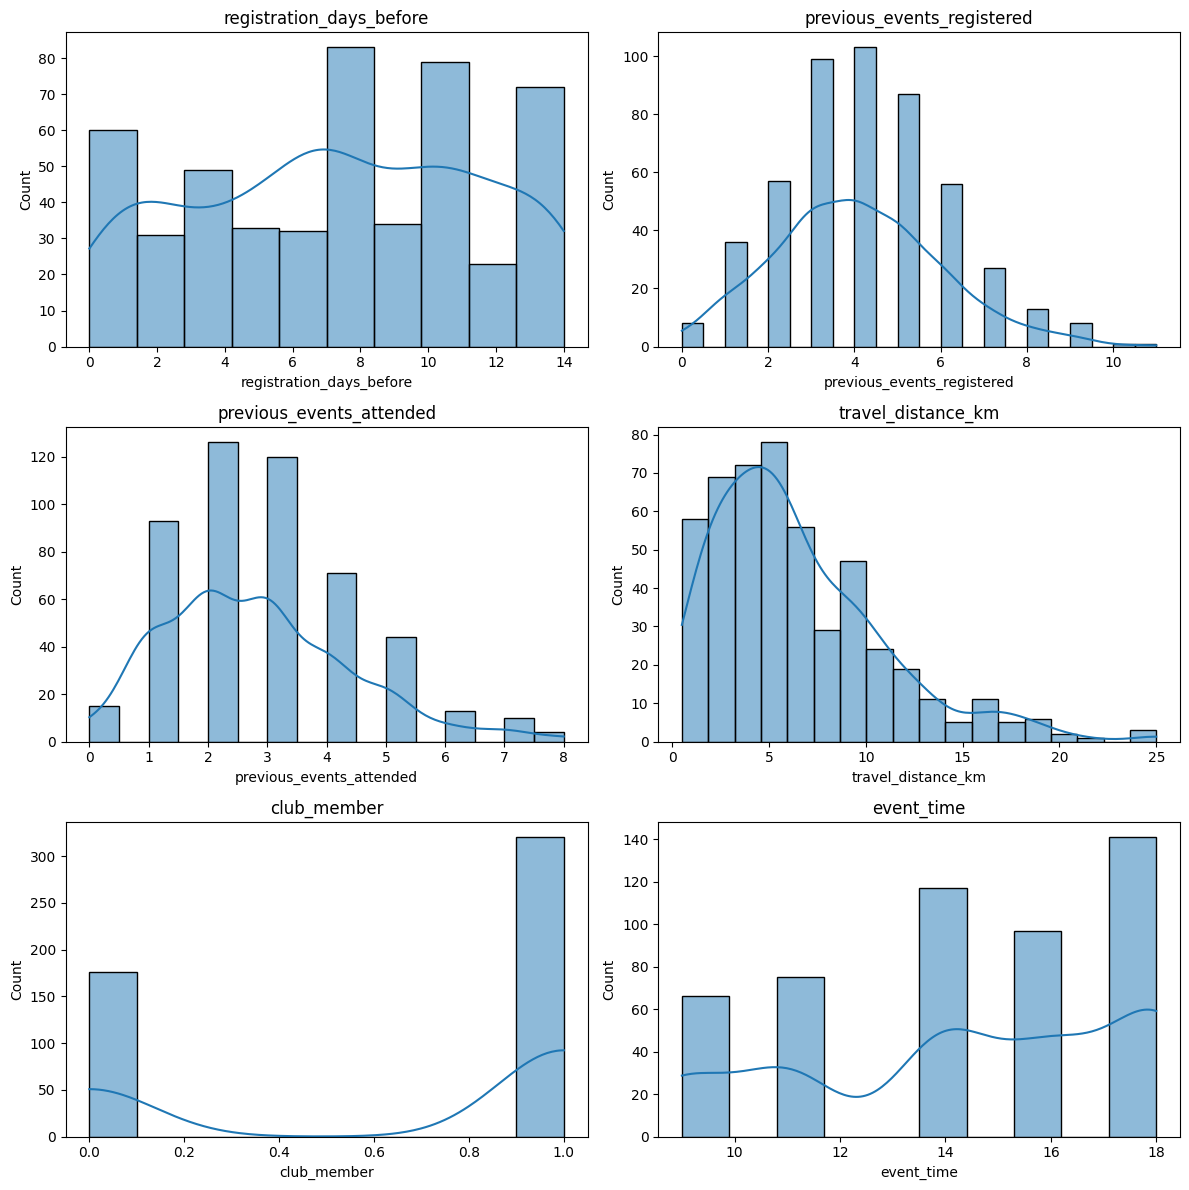

,feature,lower_bound,upper_bound,outliers,outlier_%
0,registration_days_before,-6.5000,21.5000,0,0.0000
1,previous_events_registered,0.0000,8.0000,10,2.0161
2,previous_events_attended,-1.0000,7.0000,4,0.8065
3,travel_distance_km,-5.2625,17.2375,15,3.0242
4,club_member,-1.5000,2.5000,0,0.0000
5,event_time,0.5000,28.5000,0,0.0000


In [61]:

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, col in zip(axes.flat, NUM_COLS):
    sns.histplot(labeled[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

outlier_rows = []

for col in NUM_COLS:
    q1 = labeled[col].quantile(0.25)
    q3 = labeled[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (labeled[col] < lower) | (labeled[col] > upper)

    outlier_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": int(mask.sum()),
        "outlier_%": mask.mean() * 100
    })

display(pd.DataFrame(outlier_rows).round(4))


## Categorical Structure


event_type


,count,percentage
event_type,,
Workshop,150,30.2400
Talk,106,21.3700
Hackathon,83,16.7300
Competition,82,16.5300
Social,75,15.1200


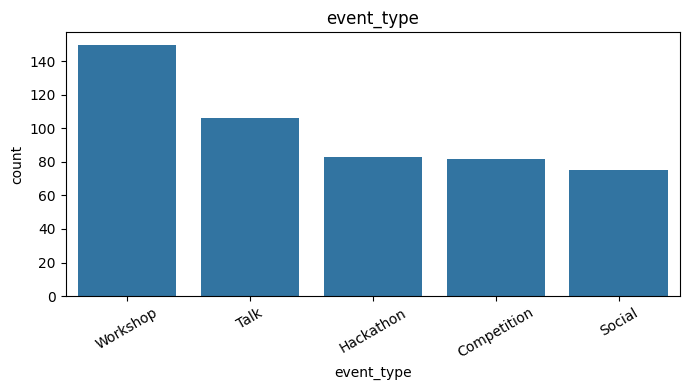


event_day


,count,percentage
event_day,,
Saturday,86,17.3400
Friday,77,15.5200
Monday,73,14.7200
Sunday,72,14.5200
Wednesday,68,13.7100
Tuesday,67,13.5100
Thursday,53,10.6900


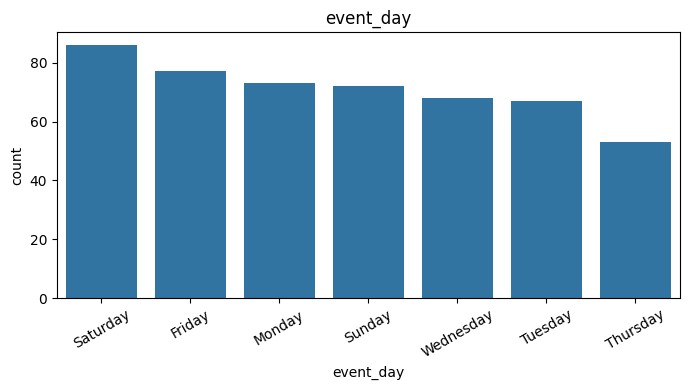

In [62]:

for col in CAT_COLS:
    table = labeled[col].value_counts(dropna=False).to_frame("count")
    table["percentage"] = table["count"] / len(labeled) * 100

    print(f"\n{col}")
    display(table.round(2))

    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=labeled,
        x=col,
        order=labeled[col].value_counts().index
    )
    plt.xticks(rotation=30)
    plt.title(col)
    plt.tight_layout()
    plt.show()


## Missingness

In [63]:

missing = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_%": train.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing.round(2))

missing_target_rows = pd.DataFrame({
    "missing_feature": [
        train[col].isna().sum() for col in NUM_COLS + CAT_COLS
    ],
    "feature": NUM_COLS + CAT_COLS
}).sort_values("missing_feature", ascending=False)

display(missing_target_rows)

# Whether missingness differs by the target.
missing_target_effect = []

for col in NUM_COLS + CAT_COLS:
    flag = labeled[col].isna().astype(int)
    if flag.nunique() > 1:
        rate = labeled.groupby(flag)[TARGET].mean()
        missing_target_effect.append({
            "feature": col,
            "attendance_if_present": rate.get(0, np.nan),
            "attendance_if_missing": rate.get(1, np.nan),
            "difference": rate.get(1, np.nan) - rate.get(0, np.nan)
        })

display(pd.DataFrame(missing_target_effect).round(4))


,missing_count,missing_%
student_id,0,0.0000
event_type,0,0.0000
registration_days_before,0,0.0000
previous_events_registered,0,0.0000
previous_events_attended,0,0.0000
club_member,0,0.0000
event_day,0,0.0000
event_time,0,0.0000
travel_distance_km,0,0.0000
attended,0,0.0000


,missing_feature,feature
0,0,registration_days_before
1,0,previous_events_registered
2,0,previous_events_attended
3,0,travel_distance_km
4,0,club_member
5,0,event_time
6,0,event_type
7,0,event_day


""


## Train–Test Shift

In [64]:

shift = []

for col in NUM_COLS:
    tr = train[col].dropna()
    te = test[col].dropna()
    stat, p = ks_2samp(tr, te)

    shift.append({
        "feature": col,
        "test": "KS",
        "statistic": stat,
        "p_value": p,
        "significant_5%": p < 0.05
    })

for col in CAT_COLS:
    table = pd.concat(
        [
            train[col].value_counts(dropna=False).rename("train"),
            test[col].value_counts(dropna=False).rename("test")
        ],
        axis=1
    ).fillna(0)

    chi2, p, _, _ = chi2_contingency(table)

    shift.append({
        "feature": col,
        "test": "Chi-square",
        "statistic": chi2,
        "p_value": p,
        "significant_5%": p < 0.05
    })

display(pd.DataFrame(shift).round(4))


,feature,test,statistic,p_value,significant_5%
0,registration_days_before,KS,0.0638,0.8617,False
1,previous_events_registered,KS,0.0164,1.0000,False
2,previous_events_attended,KS,0.0482,0.9843,False
3,travel_distance_km,KS,0.0427,0.9962,False
4,club_member,KS,0.0048,1.0000,False
5,event_time,KS,0.0157,1.0000,False
6,event_type,Chi-square,1.5728,0.8137,False
7,event_day,Chi-square,6.0266,0.4202,False


## Feature Relationships

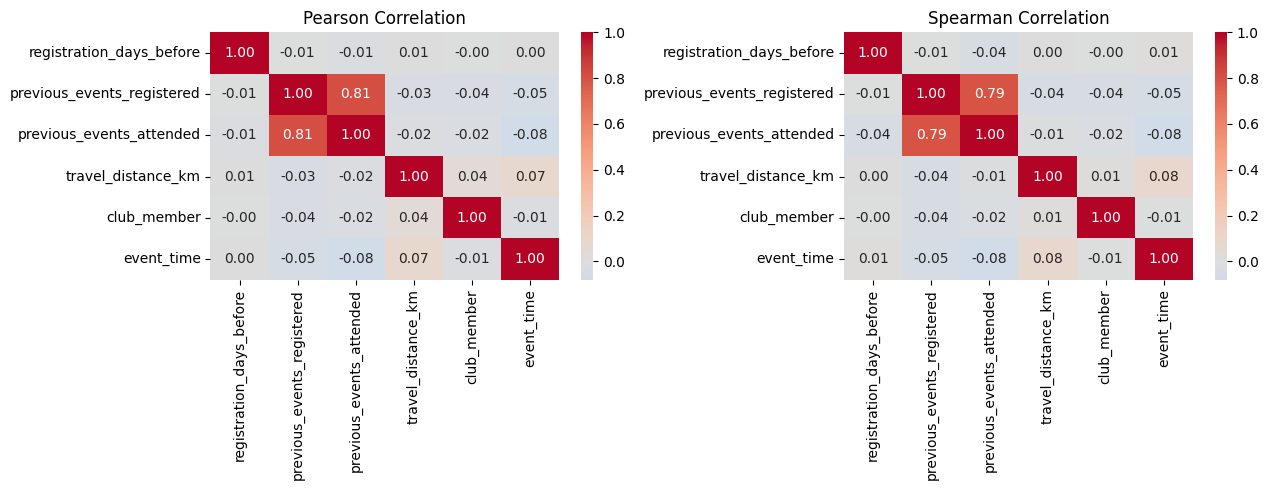

In [65]:

pearson = labeled[NUM_COLS].corr(method="pearson")
spearman = labeled[NUM_COLS].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    pearson, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=axes[0]
)
axes[0].set_title("Pearson Correlation")

sns.heatmap(
    spearman, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=axes[1]
)
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()


## Numerical Features vs Target

,feature,point_biserial_r,correlation_p,mann_whitney_U,mann_whitney_p,attend_mean,not_attend_mean,attend_median,not_attend_median
0,registration_days_before,0.2081,0.0000,35746.0000,0.0000,7.9681,6.1530,8.0000,6.0000
1,previous_events_registered,-0.0440,0.3281,27406.0000,0.4173,4.0000,4.1749,4.0000,4.0000
2,previous_events_attended,0.0013,0.9778,28763.5000,0.9347,2.8019,2.7978,3.0000,3.0000
3,travel_distance_km,-0.0963,0.0321,25257.5000,0.0281,6.1227,7.0104,5.4000,5.6000
4,club_member,0.1840,0.0000,33863.5000,0.0000,0.7125,0.5301,1.0000,1.0000
5,event_time,0.0305,0.4982,29987.0000,0.3697,14.4824,14.2842,14.0000,14.0000


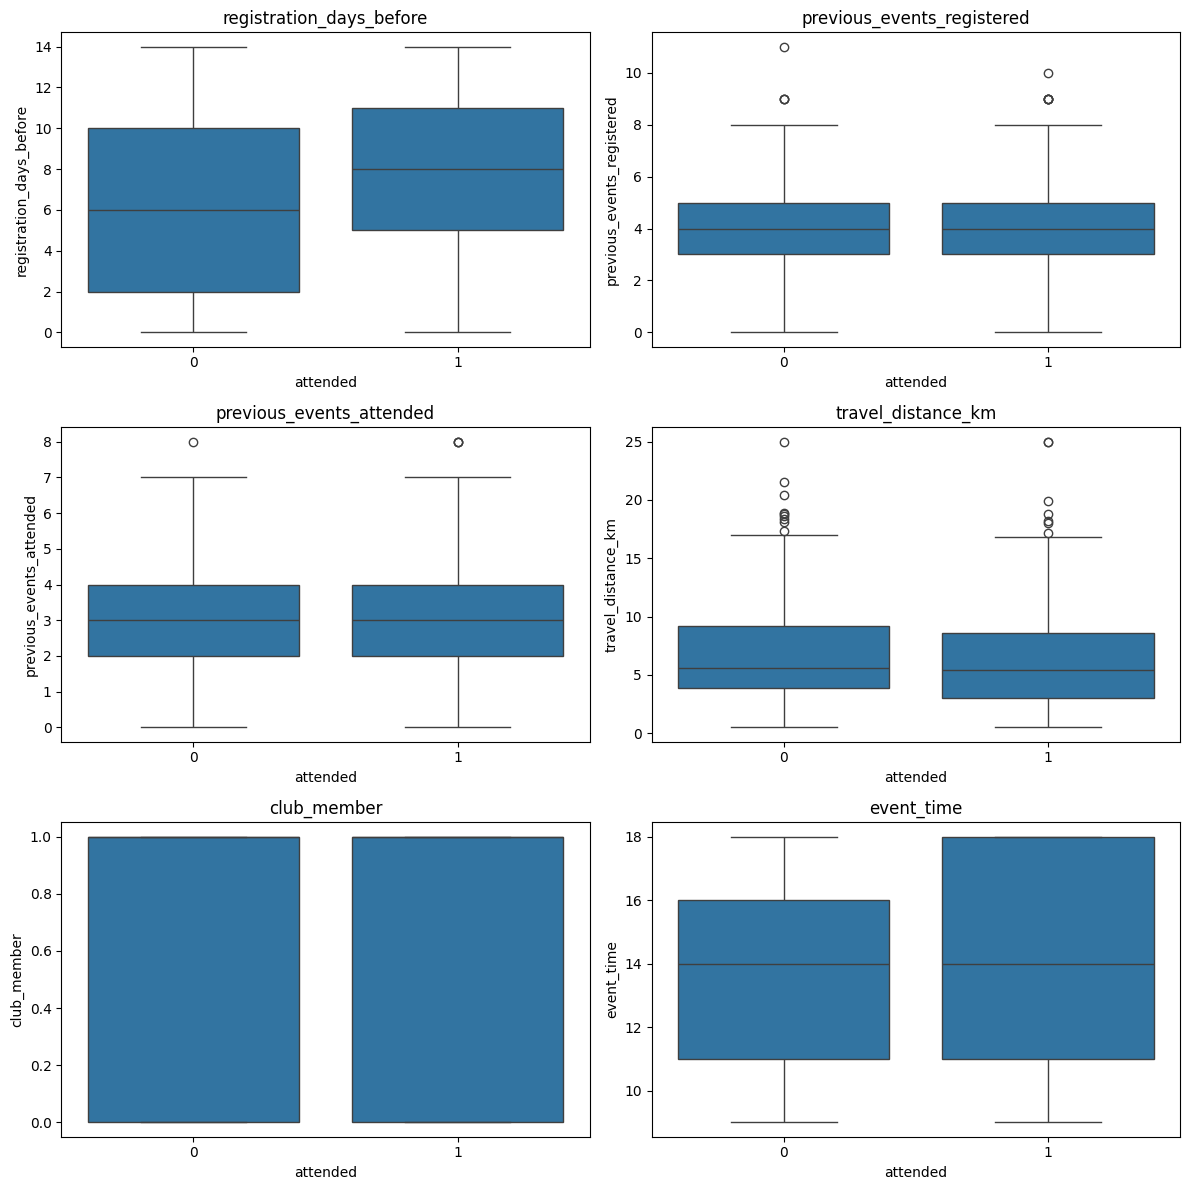

In [66]:

rows = []

for col in NUM_COLS:
    subset = labeled[[col, TARGET]].dropna()

    r, p = pointbiserialr(subset[TARGET], subset[col])

    attended = subset.loc[subset[TARGET] == 1, col]
    not_attended = subset.loc[subset[TARGET] == 0, col]

    u, mw_p = mannwhitneyu(
        attended,
        not_attended,
        alternative="two-sided"
    )

    rows.append({
        "feature": col,
        "point_biserial_r": r,
        "correlation_p": p,
        "mann_whitney_U": u,
        "mann_whitney_p": mw_p,
        "attend_mean": attended.mean(),
        "not_attend_mean": not_attended.mean(),
        "attend_median": attended.median(),
        "not_attend_median": not_attended.median()
    })

numeric_target = pd.DataFrame(rows)
display(numeric_target.round(4))

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, col in zip(axes.flat, NUM_COLS):
    sns.boxplot(data=labeled, x=TARGET, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


## Categorical Features vs Target

In [67]:

rows = []

for col in CAT_COLS + ["club_member", "event_time"]:
    if col in ["club_member", "event_time"]:
        groups = labeled.groupby(col)[TARGET].agg(["mean", "count"])
        print(f"\n{col}")
        display(groups.rename(columns={"mean": "attendance_rate"}).round(4))
        continue

    table = pd.crosstab(labeled[col], labeled[TARGET])
    chi2, p, _, _ = chi2_contingency(table)

    n = table.to_numpy().sum()
    r, k = table.shape
    denom = min(r - 1, k - 1)
    cramer_v = np.sqrt((chi2 / n) / denom) if denom else 0

    rates = labeled.groupby(col)[TARGET].agg(["mean", "count"])

    rows.append({
        "feature": col,
        "chi_square": chi2,
        "p_value": p,
        "cramers_v": cramer_v
    })

    print(f"\n{col}")
    display(rates.rename(columns={"mean": "attendance_rate"}).round(4))

display(pd.DataFrame(rows).round(4))



event_type


,attendance_rate,count
event_type,,
Competition,0.5854,82
Hackathon,0.5301,83
Social,0.5333,75
Talk,0.6604,106
Workshop,0.7400,150



event_day


,attendance_rate,count
event_day,,
Friday,0.6494,77
Monday,0.5479,73
Saturday,0.6628,86
Sunday,0.6250,72
Thursday,0.6604,53
Tuesday,0.6567,67
Wednesday,0.6176,68



club_member


,attendance_rate,count
club_member,,
0.0000,0.5114,176
1.0000,0.6969,320



event_time


,attendance_rate,count
event_time,,
9.0000,0.6364,66
11.0000,0.6267,75
14.0000,0.6068,117
16.0000,0.5670,97
18.0000,0.6950,141


,feature,chi_square,p_value,cramers_v
0,event_type,15.4813,0.0038,0.1767
1,event_day,3.0975,0.7965,0.0790


## Interactions

In [68]:

pairs = [
    ("event_type", "event_day"),
    ("event_type", "event_time"),
    ("event_type", "club_member"),
    ("event_day", "event_time"),
    ("club_member", "event_time")
]

for a, b in pairs:
    table = (
        labeled.groupby([a, b])[TARGET]
        .agg(["mean", "count"])
        .rename(columns={"mean": "attendance_rate"})
        .sort_values("attendance_rate", ascending=False)
    )

    print(f"\n{a} × {b}")
    display(table.round(4))



event_type × event_day


attendance_rate  count
event_type  event_day                        
Competition Thursday            1.0000     11
Workshop    Monday              0.9500     20
Talk        Tuesday             0.8667     15
Hackathon   Friday              0.8333     12
Workshop    Thursday            0.8000     15
            Saturday            0.8000     25
Talk        Saturday            0.7917     24
Workshop    Tuesday             0.7778     18
            Friday              0.7308     26
Talk        Wednesday           0.7143     14
Hackathon   Sunday              0.7000     10
Social      Sunday              0.7000     10
Hackathon   Wednesday           0.7000     10
Competition Wednesday           0.6923     13
Social      Saturday            0.6923     13
Talk        Friday              0.6923     13
Workshop    Sunday              0.6800     25
Social      Friday              0.6429     14
            Wednesday           0.6000     10
Competition Sunday              0.6000     10
Hackathon   Tuesday             0.5833     12
Competition Tuesday             0.5833     12
            Saturday            0.5556      9
Social      Thursday            0.5000     10
Talk        Monday              0.5000     16
Workshop    Wednesday           0.4762     21
Talk        Sunday              0.4706     17
Competition Monday              0.4667     15
Talk        Thursday            0.4286      7
Hackathon   Thursday            0.4000     10
            Monday              0.3571     14
Social      Tuesday             0.3000     10
Hackathon   Saturday            0.2667     15
Competition Friday              0.2500     12
Social      Monday              0.1250      8


event_type × event_time


,,attendance_rate,count
event_type,event_time,,
Workshop,9.0000,0.8235,17
Competition,11.0000,0.8182,11
Hackathon,9.0000,0.8000,5
Workshop,11.0000,0.7826,23
Talk,18.0000,0.7692,26
Workshop,14.0000,0.7692,39
Social,18.0000,0.7241,29
Workshop,18.0000,0.7179,39
Talk,16.0000,0.6957,23



event_type × club_member


,,attendance_rate,count
event_type,club_member,,
Workshop,1.0000,0.7895,95
Talk,1.0000,0.7183,71
Competition,1.0000,0.6792,53
Workshop,0.0000,0.6545,55
Hackathon,1.0000,0.6042,48
Social,1.0000,0.6038,53
Talk,0.0000,0.5429,35
Hackathon,0.0000,0.4286,35
Competition,0.0000,0.4138,29



event_day × event_time


attendance_rate  count
event_day event_time                        
Saturday  18.0000              0.8846     26
Sunday    11.0000              0.8182     11
Thursday  16.0000              0.8182     11
Tuesday   14.0000              0.7692     13
Sunday    18.0000              0.7500     20
Wednesday 11.0000              0.7500      8
Thursday  9.0000               0.7500      4
Tuesday   18.0000              0.7500     16
          9.0000               0.7273     11
Wednesday 9.0000               0.7143      7
Friday    9.0000               0.7000     10
          11.0000              0.6923     13
          16.0000              0.6667     15
Saturday  14.0000              0.6522     23
Sunday    14.0000              0.6429     14
Thursday  14.0000              0.6429     14
Saturday  9.0000               0.6429     14
Monday    18.0000              0.6400     25
Thursday  11.0000              0.6364     11
Friday    14.0000              0.6190     21
          18.0000              0.6111     18
Wednesday 18.0000              0.6087     23
Monday    16.0000              0.6000     10
Wednesday 16.0000              0.5882     17
Monday    9.0000               0.5714      7
Tuesday   11.0000              0.5556      9
Thursday  18.0000              0.5385     13
Wednesday 14.0000              0.5385     13
Monday    11.0000              0.5000     12
Tuesday   16.0000              0.5000     18
Sunday    9.0000               0.4615     13
Saturday  11.0000              0.4545     11
Sunday    16.0000              0.4286     14
Monday    14.0000              0.4211     19
Saturday  16.0000              0.4167     12


club_member × event_time


attendance_rate  count
club_member event_time                        
1.0000      9.0000               0.8140     43
            18.0000              0.7634     93
            14.0000              0.6486     74
            11.0000              0.6275     51
            16.0000              0.6271     59
0.0000      11.0000              0.6250     24
            18.0000              0.5625     48
            14.0000              0.5349     43
            16.0000              0.4737     38
            9.0000               0.3043     23

## Mutual Information

,feature,mutual_information
4,club_member,0.0506
0,registration_days_before,0.0443
6,event_type,0.0114
3,travel_distance_km,0.0070
2,previous_events_attended,0.0000
1,previous_events_registered,0.0000
5,event_time,0.0000
7,event_day,0.0000


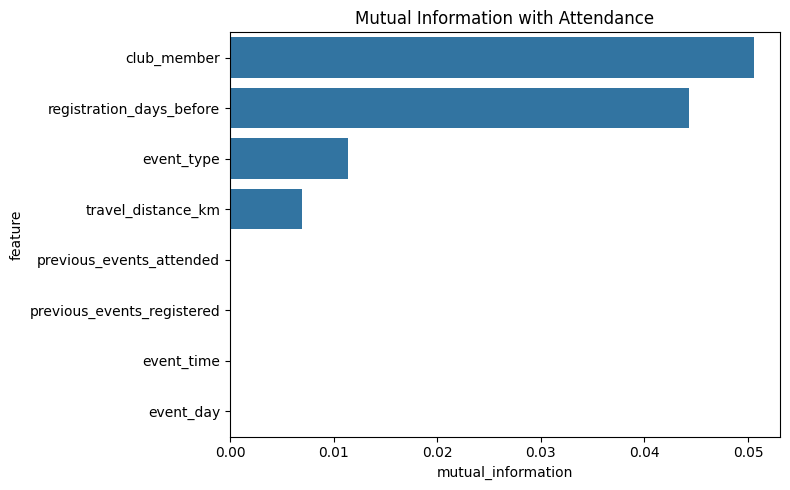

In [69]:

mi_data = labeled[NUM_COLS + CAT_COLS].copy()

for col in CAT_COLS:
    mi_data[col] = mi_data[col].astype("category").cat.codes

valid = mi_data.notna().all(axis=1)

mi = mutual_info_classif(
    mi_data.loc[valid],
    labeled.loc[valid, TARGET],
    random_state=42
)

mi_table = (
    pd.DataFrame({
        "feature": mi_data.columns,
        "mutual_information": mi
    })
    .sort_values("mutual_information", ascending=False)
)

display(mi_table.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=mi_table,
    x="mutual_information",
    y="feature"
)
plt.title("Mutual Information with Attendance")
plt.tight_layout()
plt.show()


## EDA Conclusions

In [70]:

print("Use the results above to identify:")
print("- distribution shape and possible transformations")
print("- genuine outliers versus valid extreme observations")
print("- informative and weak features")
print("- linear versus monotonic versus nonlinear relationships")
print("- categorical effects and interactions")
print("- whether missingness carries signal")
print("- train/test distribution shift")
print("- which preprocessing and feature-engineering choices are justified")


Use the results above to identify:
- distribution shape and possible transformations
- genuine outliers versus valid extreme observations
- informative and weak features
- linear versus monotonic versus nonlinear relationships
- categorical effects and interactions
- whether missingness carries signal
- train/test distribution shift
- which preprocessing and feature-engineering choices are justified
